In this notebook, you will be using 4 classification models- Logistic Regression, K Nearest Neighbours, Random Forests and Support Vector Machines (SVM).
dataset available here


Your Task

    Exploratory Data Analysis
        Use pandas to load the dataset and examine the first few rows.
        Check and handle the missing values.
        Drop any unnecessary column
        Create a Countplot to display diagnosis from magma

    Data Preprocessing, Building Models and Evaluation :
        counts of unique rows in the ‘diagnosis’ column
        map categorical values to numerical values
        Splitting the data into train and test
        Implement logistic regression and print the accuracy.
        Implement K Nearest Neighbours and print the accuracy.
        Implement Random Forests and print the accuracy.
        Implement Support Vector Machines (SVM) and print the accuracy.
        Which is the best model ?

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# "    Exploratory Data Analysis
#         Use pandas to load the dataset and examine the first few rows.
#         Check and handle the missing values.
#         Drop any unnecessary column
#         Create a Countplot to display diagnosis from magma"


df = pd.read_csv('breast_cancer.csv')
display(df.head(10))
display(df.isna().sum())
display(df.info())


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,NaN
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,NaN
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,NaN
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,NaN
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,NaN


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

None

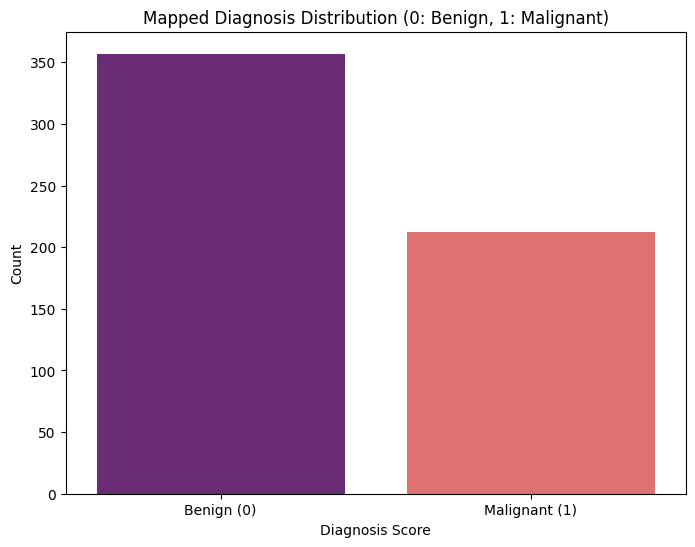

In [23]:
# The only column with missing values is Unnamed: 32. Dropping it. Also dropping ID which isn't needed for modeling or processing but just an identifier.
df = df.drop(columns=['Unnamed: 32', 'id'])
#     "map categorical values to numerical values"
# In the diagnosis column, assuming B = Benign; M = Malignant. Converting to binary, B to 0 and M to 1, to facilitate smoother machine learning:
# We use a dictionary to define the conversion
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Creating a countplot
plt.figure(figsize=(8, 6))

sns.countplot(
    data=df, 
    x='diagnosis', 
    hue='diagnosis', 
    palette='magma', 
    legend=False
)

plt.title('Mapped Diagnosis Distribution (0: Benign, 1: Malignant)')
plt.xlabel('Diagnosis Score')
plt.ylabel('Count')

plt.xticks(ticks=[0, 1], labels=['Benign (0)', 'Malignant (1)'])

plt.show()


In [24]:
# "Data Preprocessing, Building Models and Evaluation :
#     counts of unique rows in the ‘diagnosis’ column"
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [42]:
#     "Splitting the data into train and test"
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#     "Implement logistic regression and print the accuracy."

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
print(f'Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_logreg):.2%}')

Logistic Regression Accuracy: 96.49%


In [43]:
        # "Implement K Nearest Neighbours and print the accuracy."
# Train KNN with K=5 (default, good starting point)
# WHY K=5? Odd number avoids ties, 5 is a common default
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)  # MUST use scaled data for KNN!

y_pred_knn = knn.predict(X_test_scaled)

print(f"K-Nearest Neighbors (K=5) Accuracy: {accuracy_score(y_test, y_pred_knn):.2%}")

K-Nearest Neighbors (K=5) Accuracy: 95.61%


In [50]:
        # Implement Random Forests and print the accuracy.
rf = RandomForestClassifier(n_estimators=1000, random_state=42)
rf.fit(X_train, y_train)  # Using X_train, NOT X_train_scaled!

y_pred_rf = rf.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")

Random Forest Accuracy: 97.37%


In [49]:
        # Implement Support Vector Machines (SVM) and print the accuracy.

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)  # MUST use scaled data!

y_pred_svm = svm.predict(X_test_scaled)
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.2%}")

SVM Accuracy: 97.37%


In [52]:
        # Which is the best model ?
print('---Summary---')
print(f'Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_logreg):.2%}')
print(f"K-Nearest Neighbors (K=5) Accuracy: {accuracy_score(y_test, y_pred_knn):.2%}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.2%}")

---Summary---
Logistic Regression Accuracy: 96.49%
K-Nearest Neighbors (K=5) Accuracy: 95.61%
Random Forest Accuracy: 97.37%
SVM Accuracy: 97.37%


In [55]:
print("In terms of accuracy, which is the only metric we've examined here, Random Forest and SVM are tied for best model.")
print('Checking AUC too:')
from sklearn.metrics import roc_auc_score
print(f'Logistic Regression AUC Score: {roc_auc_score(y_test, y_pred_logreg):.2%}')
print(f"K-Nearest Neighbors (K=5) AUC Score: {roc_auc_score(y_test, y_pred_knn):.2%}")
print(f"Random Forest AUC Score: {roc_auc_score(y_test, y_pred_rf):.2%}")
print(f"SVM AUC Score: {roc_auc_score(y_test, y_pred_svm):.2%}")

In terms of accuracy, which is the only metric we've examined here, Random Forest and SVM are tied for best model.
Checking AUC too:
Logistic Regression AUC Score: 95.73%
K-Nearest Neighbors (K=5) AUC Score: 94.54%
Random Forest AUC Score: 96.43%
SVM AUC Score: 96.43%


In [56]:
print('Random Forest and AUC have equal AUC scores too, so at this point I would say they remain tied for best model.')

Random Forest and AUC have equal AUC scores too, so at this point I would say they remain tied for best model.
